In [41]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Japan Image Pattern Detection

## Images used

- Torii Gates https://bokksu.com/blogs/news/unlocking-the-meaning-of-japanese-religious-symbols-torii-gates-shrines-and-more?srsltid=AfmBOorejmq72H82tLwRkZgv5nzx69tsLRP8lQnf-rehWj4I4E_wgwqN

## Helpers

In [42]:
def show(img, title="", cmap="gray"):
    plt.figure(figsize=(4,4))
    if img.ndim == 2:
        plt.imshow(img, cmap=cmap)
    else:
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis("off")
    plt.show()

## Day 5

### Sample Image

In [43]:
def create_sample_image(size=(256, 256)) -> np.ndarray:
    H, W = size
    img = np.zeros((H, W, 3), np.uint8) + 255  # white background

    # rectangle
    cv2.rectangle(img, (30, 30), (120, 120), (0, 0, 0), 2)

    # circle
    cv2.circle(img, (190, 70), 40, (0, 0, 0), 2)

    # diagonal line
    cv2.line(img, (30, 200), (220, 140), (0, 0, 0), 2)

    # text
    cv2.putText(img, "JP", (140, 210),
                cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 0), 2, cv2.LINE_AA)

    return img

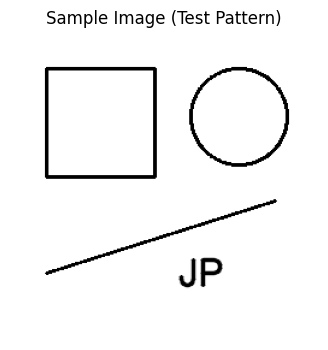

In [44]:
img_rgb = create_sample_image()
show(img_rgb, "Sample Image (Test Pattern)")

### Canny Edge Eetector

#### Grayscale and Gaussian Blur

In [45]:
def to_gray(rgb: np.ndarray) -> np.ndarray:
    return cv2.cvtColor(rgb, cv2.COLOR_RGB2GRAY)

def gaussian_blur(gray: np.ndarray,
                  ksize=(5,5),
                  sigma=1.4) -> np.ndarray:
    return cv2.GaussianBlur(gray, ksize, sigmaX=sigma)

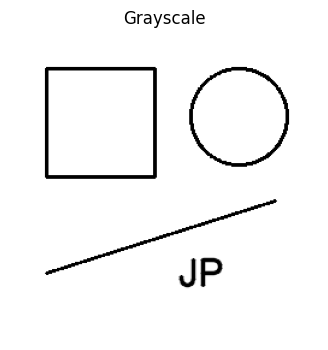

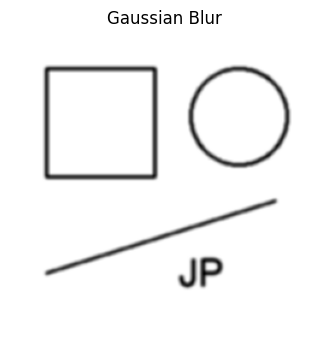

In [46]:
gray = to_gray(img_rgb)
blur = gaussian_blur(gray)

show(gray, "Grayscale")
show(blur, "Gaussian Blur")

#### Sobel Gradients

In [47]:
def sobel_gradients(blur: np.ndarray):
    Gx = cv2.Sobel(blur, cv2.CV_64F, 1, 0, ksize=3)
    Gy = cv2.Sobel(blur, cv2.CV_64F, 0, 1, ksize=3)
    magnitude = np.hypot(Gx, Gy)
    direction = np.arctan2(Gy, Gx)  # radians
    return Gx, Gy, magnitude, direction

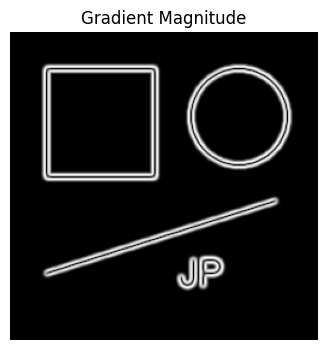

In [48]:
Gx, Gy, mag, direction = sobel_gradients(blur)
mag_disp = (mag / (mag.max() + 1e-8) * 255).astype(np.uint8)

show(mag_disp, "Gradient Magnitude")

#### Non-Maximum Suppression

In [49]:
def non_max_suppression(magnitude: np.ndarray,
                        direction: np.ndarray) -> np.ndarray:
    angle = np.degrees(direction)
    angle[angle < 0] += 180

    H, W = magnitude.shape
    Z = np.zeros_like(magnitude, dtype=np.float64)

    for i in range(1, H-1):
        for j in range(1, W-1):
            q = 0.0
            r = 0.0

            # Angle 0°
            if (0 <= angle[i, j] < 22.5) or (157.5 <= angle[i, j] <= 180):
                q = magnitude[i, j+1]
                r = magnitude[i, j-1]
            # Angle 45°
            elif 22.5 <= angle[i, j] < 67.5:
                q = magnitude[i+1, j-1]
                r = magnitude[i-1, j+1]
            # Angle 90°
            elif 67.5 <= angle[i, j] < 112.5:
                q = magnitude[i+1, j]
                r = magnitude[i-1, j]
            # Angle 135°
            elif 112.5 <= angle[i, j] < 157.5:
                q = magnitude[i-1, j-1]
                r = magnitude[i+1, j+1]

            if magnitude[i, j] >= q and magnitude[i, j] >= r:
                Z[i, j] = magnitude[i, j]
            else:
                Z[i, j] = 0.0

    return Z

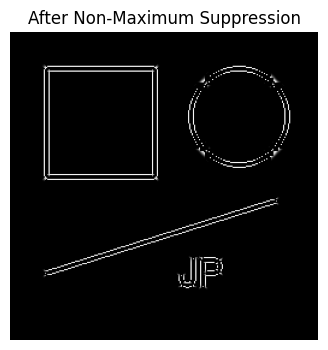

In [50]:
nms = non_max_suppression(mag, direction)
nms_disp = (nms / (nms.max() + 1e-8) * 255).astype(np.uint8)

show(nms_disp, "After Non-Maximum Suppression")

#### Double Threshold

In [51]:
def double_threshold(nms: np.ndarray,
                     high_ratio=0.15,
                     low_ratio=0.05):
    high = nms.max() * high_ratio
    low  = high * low_ratio

    strong_val = 255
    weak_val   = 75

    res = np.zeros_like(nms, dtype=np.uint8)

    strong_i, strong_j = np.where(nms >= high)
    weak_i, weak_j     = np.where((nms <= high) & (nms >= low))

    res[strong_i, strong_j] = strong_val
    res[weak_i, weak_j]     = weak_val

    return res, weak_val, strong_val

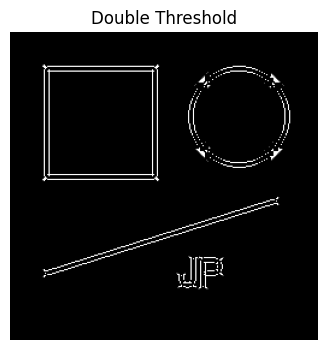

In [52]:
dt, weak_val, strong_val = double_threshold(nms, high_ratio=0.15, low_ratio=0.05)

show(dt, "Double Threshold")

#### Hysteresis

In [53]:
def hysteresis(img: np.ndarray,
               weak_val=75,
               strong_val=255) -> np.ndarray:
    H, W = img.shape
    out = img.copy()

    for i in range(1, H-1):
        for j in range(1, W-1):
            if out[i, j] == weak_val:
                # If any neighbour is strong, keep it, otherwise discard
                if np.any(out[i-1:i+2, j-1:j+2] == strong_val):
                    out[i, j] = strong_val
                else:
                    out[i, j] = 0
    return out

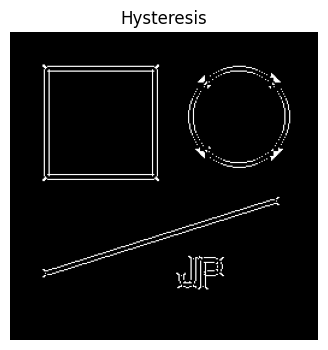

In [57]:
edges = hysteresis(dt, weak_val, strong_val)

show(edges, "Hysteresis")

#### Full Canny Pipeline

In [55]:
def canny_manual(rgb: np.ndarray,
                 blur_ksize=(5,5),
                 blur_sigma=1.4,
                 high_ratio=0.15,
                 low_ratio=0.05) -> np.ndarray:
    gray = to_gray(rgb)
    blur = gaussian_blur(gray, blur_ksize, blur_sigma)
    Gx, Gy, mag, direction = sobel_gradients(blur)
    nms = non_max_suppression(mag, direction)
    dt, weak_val, strong_val = double_threshold(nms, high_ratio, low_ratio)
    edges = hysteresis(dt, weak_val, strong_val)
    return edges

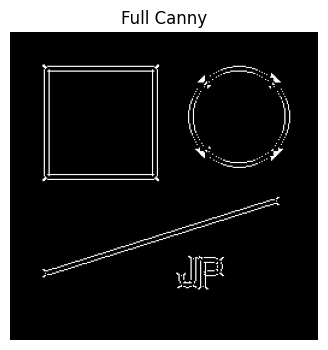

In [56]:
edges2 = canny_manual(img_rgb)

show(edges2, "Full Canny")

## Day 6

### Use Case (Japan)
Detect the **structural edges** of a Japanese **torii gate corridor** and turn the photo into a clean, line-drawing–like edge map using a classic (non-ML) algorithm.


### Problem
Real photos of torii corridors contain mixed lighting, shadows, textures (wood, foliage, stone) and background clutter.
We want a **geometry-focused edge map** that keeps the main gate and path contours while suppressing small, noisy details.


### How (Methods)

- Convert the RGB torii image to **grayscale** and apply **Gaussian blur** for noise reduction.
- Compute **Sobel gradients** to obtain gradient magnitude and direction.
- Apply **non-maximum suppression** to thin edges along the local gradient direction.
- Use **double thresholding** to label strong vs. weak edge responses.
- Perform **hysteresis** to keep only weak edges connected to strong ones → final Canny edge map.


### Why (Rationale)

- Torii corridors have **strong, high-contrast vertical and horizontal lines**, which are ideal for edge-based structure extraction.
- The **Canny edge detector** is a classic, interpretable algorithm with clear sub-steps, matching the assignment requirement.
- Separating blur, gradients, NMS, thresholds, and hysteresis lets us **tune each stage** and visually inspect its effect on the Japanese scene.


### What (Scope)

1. **Torii Corridor (Original)** – load and display the RGB photo.
2. **Intermediate Stages** – show grayscale, blurred image, gradient magnitude, and NMS result.
3. **Final Edge Map** – binary Canny edge image of the torii corridor, used as a clean structural representation of the Japanese scene.
